In [50]:
from langchain_groq import ChatGroq
from IPython.display   import Image , display
from langchain_openai import ChatOpenAI
from typing import Literal , TypedDict , Annotated , Optional , Dict , Any
from langchain_core.messages import SystemMessage, HumanMessage  , AIMessage
from langchain.chat_models import init_chat_model
from langchain_core.messages import HumanMessage, ToolMessage
from langchain_core.tools import InjectedToolArg, InjectedToolCallId, tool
from langgraph.prebuilt import InjectedState
#from langgraph.prebuilt import InjectedToolArg
from langchain_core.tools import tool
from langchain_core.messages import ToolMessage
from langchain_core.tools import InjectedToolCallId, Tool
from langgraph.types import Command
from langgraph.prebuilt import InjectedState
from langgraph.prebuilt import create_react_agent
from langgraph.prebuilt.chat_agent_executor import AgentState
from langchain.agents import create_agent
from langchain.agents import AgentState
from prompt import TASK_ANALYZER_PROMPT
from prompt import WRITE_TODOS_DESCRIPTION
from prompt import TODO_USAGE_INSTRUCTIONS
import asyncio
import json
import os 
from dotenv import load_dotenv
load_dotenv()


True

In [ ]:

llm = ChatGroq(
    model="moonshotai/kimi-k2-instruct-0905",  
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0
)

 
 

In [52]:

class Todo(TypedDict):
    """A structured task item for tracking progress through complex workflows.

    Attributes:
        content: Short, specific description of the task
        status: Current state - Pending, In Progress, or Completed
        task_type : Type of task  - Single , Parallel , Sequential
        dependencies : list of dependencies
    """
    content: str
    status: Literal["Pending", "In Progress", "Completed"]
    task_type: Literal["single", "sequential", "parallel"] 
    dependencies : list[str]


def todos_reducer(left, right):
    if left is None:
        return right
    if right is None:
        return left
    return  right 

def result_reducer(left, right):
    if left is None:
        return right
    if right is None:
        return left
    return right

class DeepAgentState(AgentState):
    """Extended agent state that includes task tracking and virtual file system.

    Inherits from LangGraph's AgentState and adds:
    - todos: List of Todo items for task planning and progress tracking
    """
    todos: Annotated[Optional[list[Todo]], todos_reducer] = None
    result: Annotated[Optional[list[str]] , result_reducer]=None

In [53]:
def convert_task_groups_to_todos_with_type(task_groups: list[dict]) -> list[Todo]:
    todos = []
    for group in task_groups:
        tasks = group.get('tasks' , [])
        task_type= group.get('task_type' , 'single')
        dependencies = group.get('dependencies' , {})

        for task in tasks:
            task_dep = dependencies.get(task , [])
            todos.append({
                "content": task ,
                "status":"Pending",
                "task_type": task_type,
                "dependencies":task_dep
            })
    return todos

In [54]:
@tool(description=WRITE_TODOS_DESCRIPTION,parse_docstring=True)
def write_todos(
    todos: list[Todo], tool_call_id: Annotated[str, InjectedToolCallId]
) -> Command:
    """Create or update the agent's TODO list for task planning and tracking.

    Args:
        todos: List of Todo items with content and status
        tool_call_id: Tool call identifier for message response

    Returns:
        Command to update agent state with new TODO list
    """
    return Command(
        update={
            "todos": todos,
            "messages": [
                ToolMessage(f"Updated todo list to {todos}", tool_call_id=tool_call_id)
            ],
        }
    )

@tool(parse_docstring=True)
def read_todos(
    state: Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId],
    
) -> str:
    """Read the current TODO list from the agent state.

    This tool allows the agent to retrieve and review the current TODO list
    to stay focused on remaining tasks and track progress through complex workflows.

    Args:
        state: Injected agent state containing the current TODO list
        tool_call_id: Injected tool call identifier for message tracking

    Returns:
        Formatted string representation of the current TODO list
    """
    todos = state.get("todos", [])
    if not todos:
        return "No todos currently in the list."

    result_lines = ["Current TODO List:"]
    for i, todo in enumerate(todos, 1):
        deps = ", ".join(todo.get("dependencies", [])) or "None"
        result_lines.append(f"{i}. {todo['content']} [{todo['status'].capitalize()}]\n   Dependencies: {deps}")

    return "\n".join(result_lines)

In [55]:
@tool(parse_docstring=True)
def task_analyzer_tool(
    message: str,
    model: Annotated[Any, InjectedToolArg] = None,  
    tool_call_id: Annotated[str, InjectedToolCallId]= InjectedToolCallId, 
) -> Command:
    """
    Analyze a user message into structured tasks.

    Args:
        message (str): The user's instruction.
        tool_call_id (str): Auto-injected by LangGraph.

    Returns:
        Command: Updates the agent's todos and logs a tool message.
    """

    global llm
    model = llm
    messages = [
        SystemMessage(content=TASK_ANALYZER_PROMPT),
        HumanMessage(content=f"User Message: {message}")
    ]

    try:
        
        response = model.invoke(messages)
        content = response.content.strip()
        print(f"LLM respone: {content}")


        if "```json" in content:
            content = content.split("```json")[1].split("```")[0].strip()
        elif "```" in content:
            content = content.split("```")[1].split("```")[0].strip()

        data = json.loads(content)
        
        
        if not isinstance(data, list):
            raise ValueError("Expected JSON array output")


        for group in data:
            for key in ["tasks", "dependencies", "task_type"]:
                if key not in group:
                    raise ValueError(f"Missing key: {key} in group")
                
        todos = convert_task_groups_to_todos_with_type(data)
        print(todos)

    except Exception as e:
        print(f" Task analysis failed: {e}")
        fallback_group = [{
            "tasks": [message],
            "dependencies": {message: []},
            "task_type": "single",
        }]
        todos = convert_task_groups_to_todos_with_type(fallback_group)
    
    return Command(
    update={
        "todos": todos,
        "messages":[ToolMessage(f"Task analyzer extracted todos:\n\n {todos}", tool_call_id=tool_call_id)
        ]
    }
)


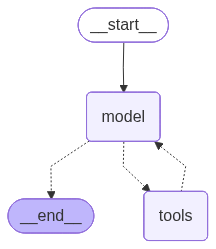

In [56]:
@tool(parse_docstring=False)
def orchestrator(
    state :Annotated[dict, InjectedState],
    tool_call_id: Annotated[str, InjectedToolCallId]) -> Command:
    '''
    Execute all tasks in the given state based on their type.
    '''
    todos = state.get('todos', [])
    if not todos:
        return Command(
            update={},
            messages=[ToolMessage("No tasks to execute.", tool_call_id=tool_call_id)]
        )


    
    result=[]

    async def run_task(task):
        task["status"] = "In Progress"
        await asyncio.sleep(0)  
        task["status"] = "Completed"
        return f"Executed {task['task_type']} task: {task['content']}"

    
    independent_tasks = [t for t in todos if not t.get("dependencies")]
    sequential_tasks_with_deps =[t for t in todos if t['task_type']=='sequential'and  t.get('dependencies')]
    

    
    if independent_tasks:
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        parallel_results= loop.run_until_complete(asyncio.gather(*(run_task(t) for t in independent_tasks)))
        loop.close()
        result.extend(parallel_results)
    
    executed_tasks = set(t['content'] for t in independent_tasks)
                            

    def resolve_dependencies(tasks):
        executed = executed_tasks.copy()
        order = []
        while len(order)< len(tasks):
            progress = False
            for t in tasks:
                dependencies=t.get('dependencies' , [])
                if all(dep in executed for dep in dependencies) and t['content'] not in executed:
                    order.append(t)
                    executed.add(t['content'])
                    progress = True
            if not progress:
                break
        return order 
    
    if sequential_tasks_with_deps:
        seq_order = resolve_dependencies(sequential_tasks_with_deps)
        for t in seq_order:
            t['status']="In Progress"
            result.append(f"Executed Sequential task: {t['content']}")
            t["status"] = "Completed"

    # all_done = all(t["status"] == "Completed" for t in todos)
    # stop_message = "All tasks completed." if all_done else "Some tasks pending."
    all_done = all(t["status"] == "Completed" for t in todos) and len(todos) > 0

    return Command(
        update={
            "todos": todos,
            "result": result,
            "messages":[
                ToolMessage(
                    content=f"Orchestrator execution completed:\n"+ "\n".join(result),
                    tool_call_id=tool_call_id
                )
            ]
        }
    )

prompt= TODO_USAGE_INSTRUCTIONS

tools= [write_todos , read_todos , task_analyzer_tool , orchestrator]


agent = create_agent(
    system_prompt=prompt , 
    tools=tools,
    state_schema= DeepAgentState,
    model=llm 
    
    
)

display(Image(agent.get_graph(xray=True).draw_mermaid_png()))




In [57]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "what is ai and ml also Download the data, clean the data, and plot the results. and list the advantages for bike and electric car",
            #"content":"Before you list the top 5 competitors, you must first search for the 'best coffee grinder 2024 reviews'. Once you've done that, also find the pricing for the top 3 and calculate the average price. Then, print all the information."
            #"content":"Translate the product catalog into French and Spanish, update the website, and then notify the sales team. Additionally, explain what localization means"
            #"content":"If today's stock market is down, fetch yesterday's data; if it's up, collect today's top gainers. Once you have data, create a summary report and email it to the investment team."
        }
    ],
    "todos": [],  
    "result": []  
    })

for m in result['messages']:
    m.pretty_print()
    



LLM respone: [
  {
    "tasks": ["Define AI and ML"],
    "dependencies": {"Define AI and ML": []},
    "task_type": "single"
  },
  {
    "tasks": ["Download data", "Clean data", "Plot results"],
    "dependencies": {
      "Download data": [],
      "Clean data": ["Download data"],
      "Plot results": ["Clean data"]
    },
    "task_type": "sequential"
  },
  {
    "tasks": ["List advantages of bike", "List advantages of electric car"],
    "dependencies": {
      "List advantages of bike": [],
      "List advantages of electric car": []
    },
    "task_type": "parallel"
  }
]
[{'content': 'Define AI and ML', 'status': 'Pending', 'task_type': 'single', 'dependencies': []}, {'content': 'Download data', 'status': 'Pending', 'task_type': 'sequential', 'dependencies': []}, {'content': 'Clean data', 'status': 'Pending', 'task_type': 'sequential', 'dependencies': ['Download data']}, {'content': 'Plot results', 'status': 'Pending', 'task_type': 'sequential', 'dependencies': ['Clean data'

In [60]:
result.get('todos')


[{'content': 'Define AI and ML',
  'status': 'Completed',
  'task_type': 'single',
  'dependencies': []},
 {'content': 'Download data',
  'status': 'Completed',
  'task_type': 'sequential',
  'dependencies': []},
 {'content': 'Clean data',
  'status': 'Completed',
  'task_type': 'sequential',
  'dependencies': ['Download data']},
 {'content': 'Plot results',
  'status': 'Completed',
  'task_type': 'sequential',
  'dependencies': ['Clean data']},
 {'content': 'List advantages of bike',
  'status': 'Completed',
  'task_type': 'parallel',
  'dependencies': []},
 {'content': 'List advantages of electric car',
  'status': 'Completed',
  'task_type': 'parallel',
  'dependencies': []}]

In [61]:
result.get('result')

['Executed single task: Define AI and ML',
 'Executed sequential task: Download data',
 'Executed parallel task: List advantages of bike',
 'Executed parallel task: List advantages of electric car',
 'Executed Sequential task: Clean data',
 'Executed Sequential task: Plot results']

## Experim